<a href="https://colab.research.google.com/github/Jay21-bot/Fraud_Detection/blob/main/Fraud_Detection_Datacleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from google.colab import files
uploaded = files.upload()

Saving Fraud.csv to Fraud (2).csv


In [79]:
df = pd.read_csv("Fraud.csv")
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [80]:
columns_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud']
df = df.drop(columns=columns_to_drop, axis=1)


In [81]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])


In [82]:
df = df.drop(['step'], axis=1)
scaler = StandardScaler()
cols_to_scale = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


In [83]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [84]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [85]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9996519085425458
Confusion Matrix:
 [[209483      8]
 [    65    159]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    209491
           1       0.95      0.71      0.81       224

    accuracy                           1.00    209715
   macro avg       0.98      0.85      0.91    209715
weighted avg       1.00      1.00      1.00    209715



In [86]:
# Take a smaller subset of the dataset for faster training
X_resampled_subset = X_resampled[:10000]  # Adjust this size as needed
y_resampled_subset = y_resampled[:10000]

# Re-train the model with the subset
model.fit(X_resampled_subset, y_resampled_subset)


RandomForestClassifier(random_state=42)

In [87]:
import lightgbm as lgb

# Train with LightGBM
train_data = lgb.Dataset(X_resampled, label=y_resampled)
params = {'objective': 'binary', 'metric': 'binary_error'}
model_lgb = lgb.train(params, train_data, num_boost_round=100)

# Make predictions
y_pred_lgb = model_lgb.predict(X_test)


[LightGBM] [Info] Number of positive: 918, number of negative: 918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001639 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1280
[LightGBM] [Info] Number of data points in the train set: 1836, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [88]:
# Reduce number of estimators (trees) in RandomForest
model = RandomForestClassifier(n_estimators=50, random_state=42)  # Set to a lower number
model.fit(X_resampled, y_resampled)


RandomForestClassifier(n_estimators=50, random_state=42)

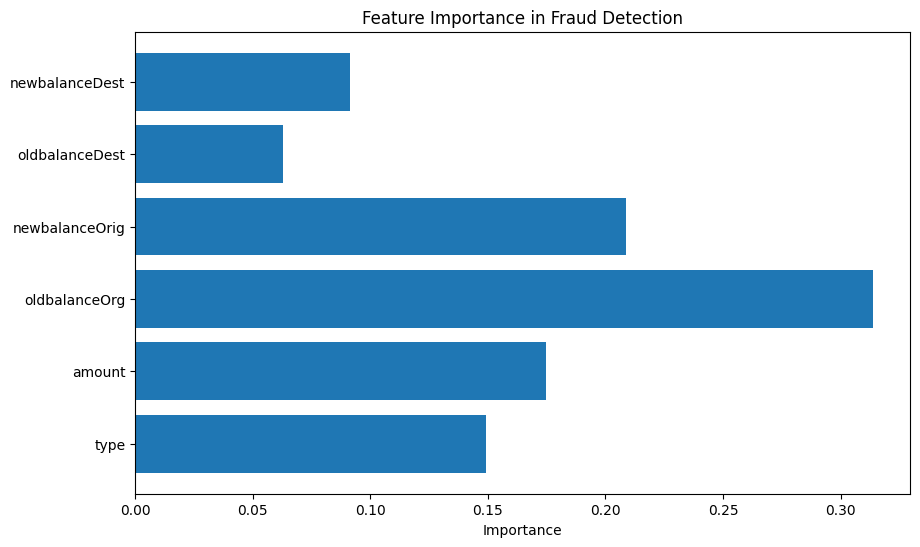

In [89]:
import matplotlib.pyplot as plt

# Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("Feature Importance in Fraud Detection")
plt.show()


In [90]:
import joblib

# Save the model to a file
joblib.dump(model, 'fraud_detector_model.pkl')

# Load it later using joblib:
# model = joblib.load('fraud_detector_model.pkl')


['fraud_detector_model.pkl']

In [91]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9996519085425458
Confusion Matrix:
 [[209483      8]
 [    65    159]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    209491
           1       0.95      0.71      0.81       224

    accuracy                           1.00    209715
   macro avg       0.98      0.85      0.91    209715
weighted avg       1.00      1.00      1.00    209715



In [92]:
from imblearn.under_sampling import RandomUnderSampler

# Undersample the majority class
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)

# Retrain model on undersampled data
model.fit(X_resampled, y_resampled)


RandomForestClassifier(n_estimators=50, random_state=42)

In [93]:
import xgboost as xgb

# Train XGBoost
model_xgb = xgb.XGBClassifier(random_state=42)
model_xgb.fit(X_resampled, y_resampled)

# Make predictions and evaluate
y_pred_xgb = model_xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))


Accuracy: 0.9810838518942374
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99    209491
           1       0.05      0.97      0.10       224

    accuracy                           0.98    209715
   macro avg       0.53      0.97      0.54    209715
weighted avg       1.00      0.98      0.99    209715



In [94]:
from sklearn.model_selection import GridSearchCV

# Define parameters to tune
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Grid Search for RandomForest
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_resampled, y_resampled)

# Get best parameters and retrain the model
print("Best parameters:", grid_search.best_params_)
model = grid_search.best_estimator_
model.fit(X_resampled, y_resampled)


Best parameters: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}


RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=200,
                       random_state=42)

In [95]:
from sklearn.metrics import precision_recall_curve

# Get probabilities for fraud (class 1)
y_prob = model.predict_proba(X_test)[:, 1]

# Adjust the threshold (for example, to 0.2)
threshold = 0.2  # You can adjust this threshold as needed
y_pred_adjusted = (y_prob > threshold).astype(int)

# Re-evaluate the adjusted predictions
print("Accuracy:", accuracy_score(y_test, y_pred_adjusted))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_adjusted))
print("Classification Report:\n", classification_report(y_test, y_pred_adjusted))


Accuracy: 0.9119805450253916
Confusion Matrix:
 [[191036  18455]
 [     4    220]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95    209491
           1       0.01      0.98      0.02       224

    accuracy                           0.91    209715
   macro avg       0.51      0.95      0.49    209715
weighted avg       1.00      0.91      0.95    209715



In [96]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Initialize XGBoost model with class weights
model_xgb = xgb.XGBClassifier(scale_pos_weight=10, random_state=42)

# Train the model on the resampled dataset
model_xgb.fit(X_resampled, y_resampled)

# Predict on the test data
y_pred_xgb = model_xgb.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))


Accuracy: 0.975357032162697
Confusion Matrix:
 [[204329   5162]
 [     6    218]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99    209491
           1       0.04      0.97      0.08       224

    accuracy                           0.98    209715
   macro avg       0.52      0.97      0.53    209715
weighted avg       1.00      0.98      0.99    209715



In [97]:
# Get predicted probabilities for fraud class (class 1)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

# Adjust threshold (e.g., 0.3 or 0.4)
threshold = 0.3
y_pred_adjusted_xgb = (y_prob_xgb > threshold).astype(int)

# Re-evaluate the adjusted predictions
print("Accuracy:", accuracy_score(y_test, y_pred_adjusted_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_adjusted_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_adjusted_xgb))


Accuracy: 0.969849557733114
Confusion Matrix:
 [[203174   6317]
 [     6    218]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98    209491
           1       0.03      0.97      0.06       224

    accuracy                           0.97    209715
   macro avg       0.52      0.97      0.52    209715
weighted avg       1.00      0.97      0.98    209715



In [98]:
from imblearn.combine import SMOTEENN

# Apply SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)
X_resampled_enn, y_resampled_enn = smote_enn.fit_resample(X_train, y_train)

# Train the model again on the new resampled data
model_xgb.fit(X_resampled_enn, y_resampled_enn)

# Make predictions
y_pred_xgb_enn = model_xgb.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_enn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_enn))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_enn))


Accuracy: 0.9910688315094295
Confusion Matrix:
 [[207627   1864]
 [     9    215]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    209491
           1       0.10      0.96      0.19       224

    accuracy                           0.99    209715
   macro avg       0.55      0.98      0.59    209715
weighted avg       1.00      0.99      0.99    209715



In [99]:
import joblib

# Save the trained model to a file
joblib.dump(model, 'fraud_detection_model.pkl')
print("Model saved as 'fraud_detection_model.pkl'")


Model saved as 'fraud_detection_model.pkl'


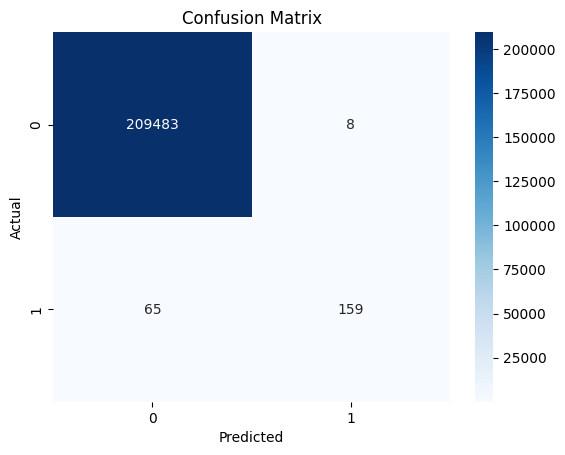

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


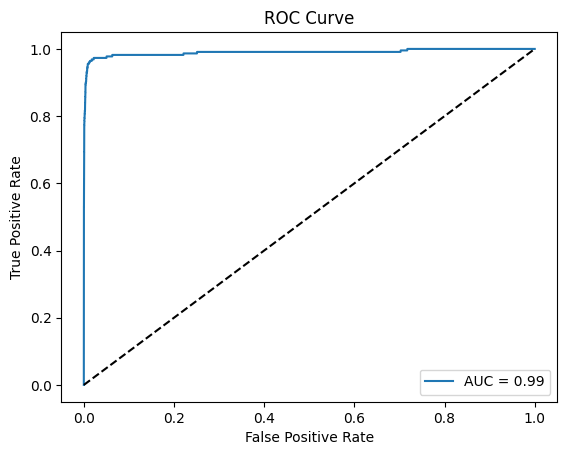

In [101]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
